# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants
g = 9.81
d = 4000

# Analytic answers
t_hit = np.sqrt((2 * d) / g)
v_hit = -g * t_hit

print(f"analytic time = {t_hit:.3f} s")
print(f"analytic velocity = {v_hit:.3f} m/s")

# defining the system
def fall(t, z):
    
    y, v = z
    
    # finding derivatives
    dydt = v
    dvdt = -g
    
    return [dydt, dvdt]

# initial values
z0 = [0, 0]

# time values
t_span = (0, 35)
t_eval = np.linspace(0, 35, 700)

# solving the system and storing solutions
sol = solve_ivp(fall, t_span, z0, t_eval=t_eval)

t = sol.t
y = sol.y[0]
v = sol.y[1]

analytic time = 28.557 s
analytic velocity = -280.143 m/s


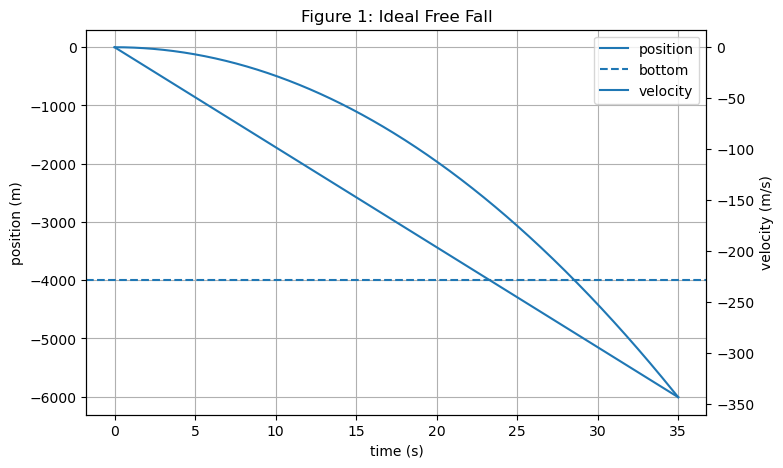

In [2]:
# plotting the results
fig, ax1 = plt.subplots(figsize=(8,5))

# plotting position
ax1.plot(t, y, label='position')
ax1.axhline(-d, linestyle='--', label='bottom')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('position (m)')
ax1.set_title('Figure 1: Ideal Free Fall')
ax1.grid()

# plotting velocity
ax2 = ax1.twinx()

ax2.plot(t, v, label='velocity')
ax2.set_ylabel('velocity (m/s)')

# combining legends
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2)

plt.show()

In [3]:
# defining the event
def hit_bottom(t, z):
    
    y, v = z
    
    return y + d

# stopping at the bottom
hit_bottom.terminal = True
hit_bottom.direction = -1

# solving with event detection
sol2 = solve_ivp(fall, t_span, z0, events=hit_bottom)

# storing event time
t_num = sol2.t_events[0][0]

# finding difference
diff = t_num - t_hit

print(f"analytic = {t_hit:.6f} s")
print(f"numerical = {t_num:.6f} s")
print(f"difference = {diff:.6e} s")

analytic = 28.556862 s
numerical = 28.556862 s
difference = -7.105427e-15 s


### Part 1 Discussion

In the ideal no-drag case, the object falls with constant acceleration. The position curve is parabolic because the distance fallen grows like t^2, while the velocity decreases linearly with time. The numerical event time matches the analytic free-fall time almost exactly, with only a tiny numerical roundoff difference.

---

## Part 2:

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



In [4]:
# constants
R = 6.371e6
g0 = 9.81
d = 4000

# defining variable g
def g_var(r):
    return g0 * (r / R)

In [5]:
# the no-drag system
def fall_g(t, z):
    
    r, v = z
    
    # derivatives
    drdt = v
    dvdt = -g_var(r)
    
    return [drdt, dvdt]

# the bottom event
def hit_bottom2(t, z):
    
    r, v = z
    
    return r - (R - d)

hit_bottom2.terminal = True
hit_bottom2.direction = -1

# initial values
z0 = [R, 0]

sol_g = solve_ivp(fall_g, (0, 40), z0, events=hit_bottom2, dense_output=True)

t_g = sol_g.t
r_g = sol_g.y[0]
v_g = sol_g.y[1]

# changing radius to height above bottom
h_g = r_g - (R - d)

# getting hit time
t_g_hit = sol_g.t_events[0][0]

print(f"hit time with variable g = {t_g_hit:.6f} s")
print(f"constant g hit time = {t_hit:.6f} s")
print(f"difference = {t_g_hit - t_hit:.6e} s")

hit time with variable g = 28.558357 s
constant g hit time = 28.556862 s
difference = 1.494329e-03 s


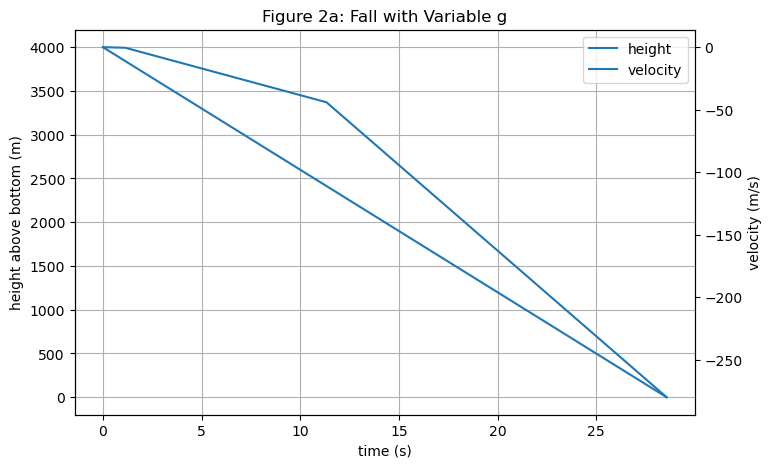

In [6]:
# plotting Figure 2
fig, ax1 = plt.subplots(figsize=(8,5))

# plotting height
ax1.plot(t_g, h_g, label='height')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('height above bottom (m)')
ax1.set_title('Figure 2a: Fall with Variable g')
ax1.grid()

# plotting velocity
ax2 = ax1.twinx()
ax2.plot(t_g, v_g, label='velocity')
ax2.set_ylabel('velocity (m/s)')

# combining legends
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2)

plt.show()

In [7]:
# drag constants
gamma = 2
vt = 50
alpha = g0 / vt**gamma

# defining the drag system
def fall_drag(t, z):
    
    r, v = z
    
    # finding gravity and drag
    grav = -g_var(r)
    drag = -alpha * abs(v)**gamma * np.sign(v)
    
    # finding derivatives
    drdt = v
    dvdt = grav + drag
    
    return [drdt, dvdt]

# solving with drag
sol_d = solve_ivp(fall_drag, (0, 500), z0, events=hit_bottom2)

t_d = sol_d.t
r_d = sol_d.y[0]
v_d = sol_d.y[1]

# changing radius to height above bottom
h_d = r_d - (R - d)

# getting hit time
t_d_hit = sol_d.t_events[0][0]

print(f"hit time with drag = {t_d_hit:.6f} s")
print(f"hit time without drag = {t_g_hit:.6f} s")
print(f"difference = {t_d_hit - t_g_hit:.6f} s")

hit time with drag = 83.543096 s
hit time without drag = 28.558357 s
difference = 54.984739 s


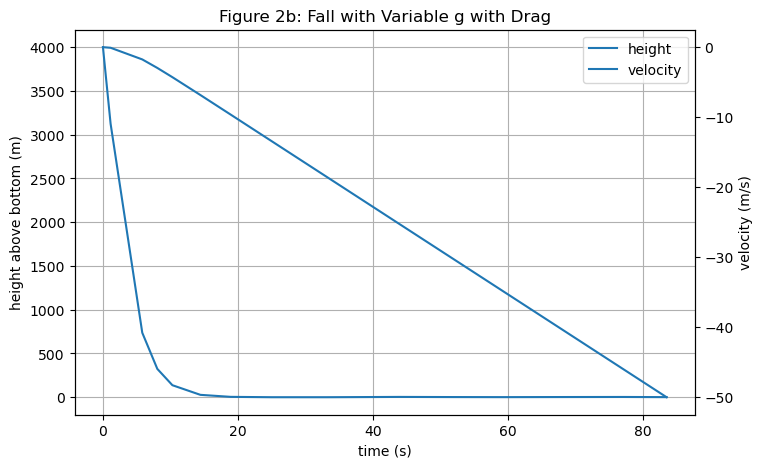

In [8]:
# plotting with drag
fig, ax1 = plt.subplots(figsize=(8,5))

# plotting height
ax1.plot(t_d, h_d, label='height')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('height above bottom (m)')
ax1.set_title('Figure 2b: Fall with Variable g with Drag')
ax1.grid()

# plotting velocity
ax2 = ax1.twinx()
ax2.plot(t_d, v_d, label='velocity')
ax2.set_ylabel('velocity (m/s)')

# combining legends
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2)

plt.show()

### Part 2 discussion

Using variable gravity makes the fall time only slightly longer. This is because the shaft is only 4 km deep, which is very small compared with Earth's radius, so gravity barely changes during the fall.

Adding drag has a much bigger effect. I calibrated alpha by using a terminal speed of 50 m/s, so alpha = g / vt^2. With drag, the object speeds up at first but then approaches terminal velocity, making the fall time much longer.

---

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




In [9]:
# rotation
Omega = 2 * np.pi / (24 * 60 * 60)

# defining coriolis system-no drag
def fall_cor(t, z):
    
    x, vx, y, vy = z
    
    # gravity
    r = R - y
    g_now = g_var(r)
    
    # derivatives
    dxdt = vx
    dvxdt = 2 * Omega * vy
    dydt = vy
    dvydt = g_now - 2 * Omega * vx
    
    return [dxdt, dvxdt, dydt, dvydt]

# defining bottom event
def hit_bottom3(t, z):
    
    x, vx, y, vy = z
    
    return y - d

hit_bottom3.terminal = True
hit_bottom3.direction = 1

# defining wall event
def hit_wall(t, z):
    
    x, vx, y, vy = z
    
    return 2.5 - abs(x)

hit_wall.terminal = True
hit_wall.direction = -1

# setting initial values
z0_cor = [0, 0, 0, 0]

# solving
sol_cor = solve_ivp(
    fall_cor,
    (0, 40),
    z0_cor,
    events=[hit_bottom3, hit_wall],
    max_step=0.05
)

# storing values
t_c = sol_cor.t
x_c = sol_cor.y[0]
y_c = sol_cor.y[2]

# checking event times
bottom_times = sol_cor.t_events[0]
wall_times = sol_cor.t_events[1]

if len(bottom_times) > 0:
    print(f"reaches bottom at t = {bottom_times[0]:.3f} s")
else:
    print("does not reach bottom first")

if len(wall_times) > 0:
    print(f"hits wall at t = {wall_times[0]:.3f} s")
else:
    print("does not hit wall first")

does not reach bottom first
hits wall at t = 21.907 s


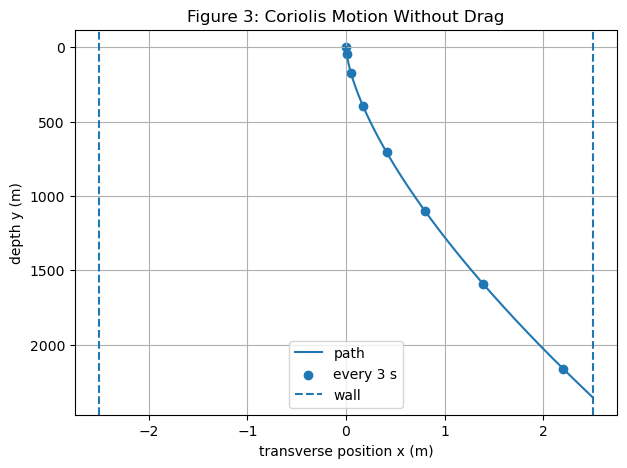

In [10]:
# plotting Figure 3
fig, ax = plt.subplots(figsize=(7,5))

# plotting path
ax.plot(x_c, y_c, label='path')

# plotting dots every few seconds
dot_times = np.arange(0, t_c[-1], 3)
x_dot = np.interp(dot_times, t_c, x_c)
y_dot = np.interp(dot_times, t_c, y_c)

ax.scatter(x_dot, y_dot, label='every 3 s')

# adding shaft walls
ax.axvline(2.5, linestyle='--', label='wall')
ax.axvline(-2.5, linestyle='--')

# labeling plot
ax.set_xlabel('transverse position x (m)')
ax.set_ylabel('depth y (m)')
ax.set_title('Figure 3: Coriolis Motion Without Drag')
ax.invert_yaxis()
ax.grid()
ax.legend()

plt.show()

In [11]:
# defining coriolis system with drag
def fall_cor_drag(t, z):
    
    x, vx, y, vy = z
    
    # finding gravity
    r = R - y
    g_now = g_var(r)
    
    # finding speed
    speed = np.sqrt(vx**2 + vy**2)
    
    # finding drag terms
    drag_x = -alpha * speed * vx
    drag_y = -alpha * speed * vy
    
    # finding derivatives
    dxdt = vx
    dvxdt = 2 * Omega * vy + drag_x
    dydt = vy
    dvydt = g_now - 2 * Omega * vx + drag_y
    
    return [dxdt, dvxdt, dydt, dvydt]

# solving with drag
sol_cd = solve_ivp(
    fall_cor_drag,
    (0, 500),
    z0_cor,
    events=[hit_bottom3, hit_wall],
    max_step=0.05
)

# storing values
t_cd = sol_cd.t
x_cd = sol_cd.y[0]
y_cd = sol_cd.y[2]

# checking event times
bottom_drag = sol_cd.t_events[0]
wall_drag = sol_cd.t_events[1]

if len(bottom_drag) > 0:
    print(f"with drag, reaches bottom at t = {bottom_drag[0]:.3f} s")
else:
    print("with drag, does not reach bottom first")

if len(wall_drag) > 0:
    print(f"with drag, hits wall at t = {wall_drag[0]:.3f} s")
else:
    print("with drag, does not hit wall first")

with drag, does not reach bottom first
with drag, hits wall at t = 75.455 s


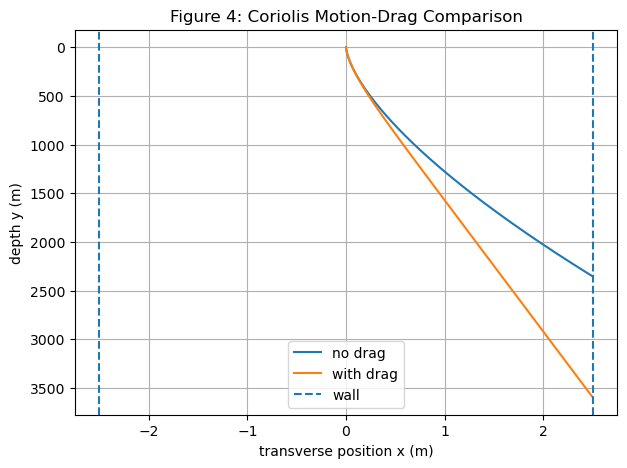

In [12]:
# plotting drag comparison
fig, ax = plt.subplots(figsize=(7,5))

# plotting paths
ax.plot(x_c, y_c, label='no drag')
ax.plot(x_cd, y_cd, label='with drag')

# adding shaft walls
ax.axvline(2.5, linestyle='--', label='wall')
ax.axvline(-2.5, linestyle='--')

# labeling plot
ax.set_xlabel('transverse position x (m)')
ax.set_ylabel('depth y (m)')
ax.set_title('Figure 4: Coriolis Motion-Drag Comparison')
ax.invert_yaxis()
ax.grid()
ax.legend()

plt.show()

### Part 3 discussion

Without drag, the object moves sideways because of the Coriolis force. For a 5 m wide shaft, the object hits the wall before reaching the bottom.

With drag, the object falls more slowly, so the Coriolis effect has more time to push it sideways. Drag does make a difference because it changes the fall time and the sideways motion. However, even with drag, it still hits the wall before the bottom.

---

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





In [13]:
# constants
R = 6.371e6
g0 = 9.81

# defining tunnel system
def tunnel(t, z):
    
    y, v = z
    
    # finding derivatives
    dydt = v
    dvdt = -(g0 / R) * y
    
    return [dydt, dvdt]

# defining center event
def hit_center(t, z):
    
    y, v = z
    
    return y

hit_center.terminal = False
hit_center.direction = -1

# defining other side event
def hit_other_side(t, z):
    
    y, v = z
    
    return y + R

hit_other_side.terminal = True
hit_other_side.direction = -1

# setting initial values
z0_4 = [R, 0]

# solving
sol4 = solve_ivp(
    tunnel,
    (0, 7000),
    z0_4,
    events=[hit_center, hit_other_side],
    max_step=1
)

# storing values
t4 = sol4.t
y4 = sol4.y[0]
v4 = sol4.y[1]

# storing center time
t_center = sol4.t_events[0][0]

# getting other side time from symmetry
t_cross = 2 * t_center

# full tunnel period
T_tunnel = 4 * t_center

# finding center speed
v_center = np.interp(t_center, t4, v4)

print(f"time to center = {t_center:.3f} s")
print(f"speed at center = {abs(v_center):.3f} m/s")

print(f"time to other side = {t_cross:.3f} s")

print(f"full tunnel period = {T_tunnel:.3f} s")

time to center = 1265.870 s
speed at center = 7905.662 m/s
time to other side = 2531.740 s
full tunnel period = 5063.481 s


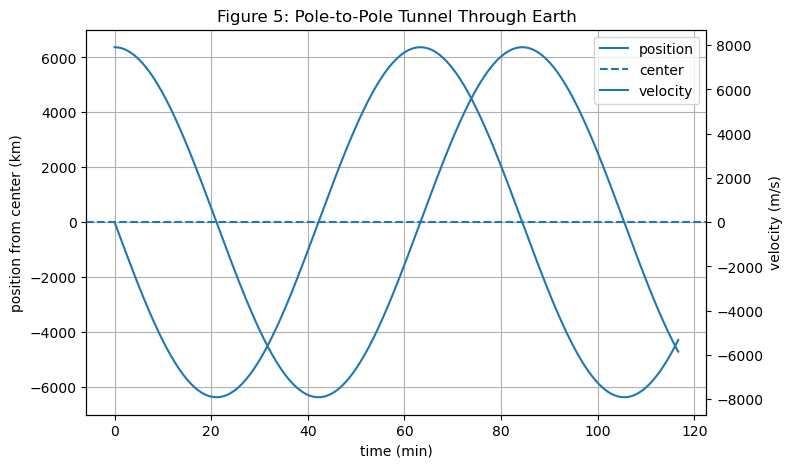

In [14]:
# plotting Figure 4
fig, ax1 = plt.subplots(figsize=(8,5))

# plotting position
ax1.plot(t4 / 60, y4 / 1000, label='position')
ax1.axhline(0, linestyle='--', label='center')
ax1.set_xlabel('time (min)')
ax1.set_ylabel('position from center (km)')
ax1.set_title('Figure 5: Pole-to-Pole Tunnel Through Earth')
ax1.grid()

# plotting velocity
ax2 = ax1.twinx()
ax2.plot(t4 / 60, v4, label='velocity')
ax2.set_ylabel('velocity (m/s)')

# combining legends
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()

ax1.legend(l1 + l2, lab1 + lab2)

plt.show()

In [15]:
# finding orbital period
v_orb = np.sqrt(g0 * R)
T_orb = 2 * np.pi * R / v_orb

# finding tunnel period
T_tunnel = 2 * t_cross

print(f"orbital speed = {v_orb:.3f} m/s")
print(f"orbital period = {T_orb:.3f} s")


print(f"full tunnel period = {T_tunnel:.3f} s")
print(f"difference = {T_tunnel - T_orb:.6e} s")

orbital speed = 7905.663 m/s
orbital period = 5063.481 s
full tunnel period = 5063.481 s
difference = 1.818989e-12 s


### Part 4 discussion

The motion looks like simple harmonic motion. The object speeds up as it falls toward the center, reaches its maximum speed at the center, and then slows down as it moves toward the other side of Earth.

The time to reach the center is about one quarter of the full oscillation period. The time to reach the other side is about one half of the full period.

The full tunnel period is basically the same as the circular orbital period near Earth's surface because both come from the same acceleration form.

---

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

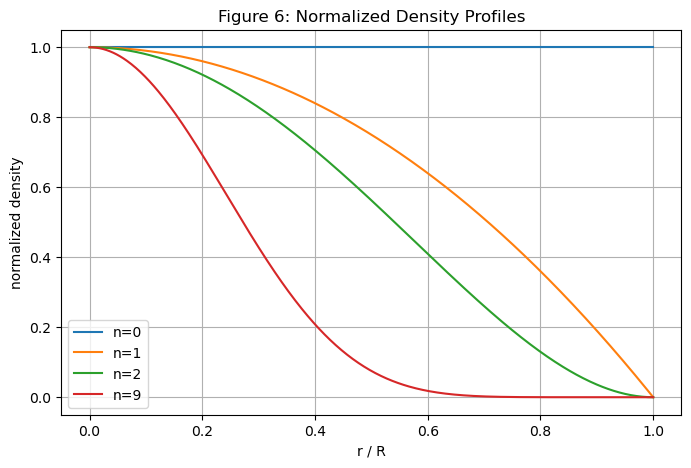

In [16]:
from scipy.integrate import quad

# setting values
ns = [0, 1, 2, 9]
r = np.linspace(0, R, 500)

# defining density shape
def rho_shape(r, n):
    return (1 - r**2 / R**2)**n

# plotting Figure 5
fig, ax = plt.subplots(figsize=(8,5))

for n in ns:
    
    # normalized density
    ax.plot(r / R, rho_shape(r, n), label=f'n={n}')

ax.set_xlabel('r / R')
ax.set_ylabel('normalized density')
ax.set_title('Figure 6: Normalized Density Profiles')
ax.grid()
ax.legend()

plt.show()

### Part 5, Section B (Forces)

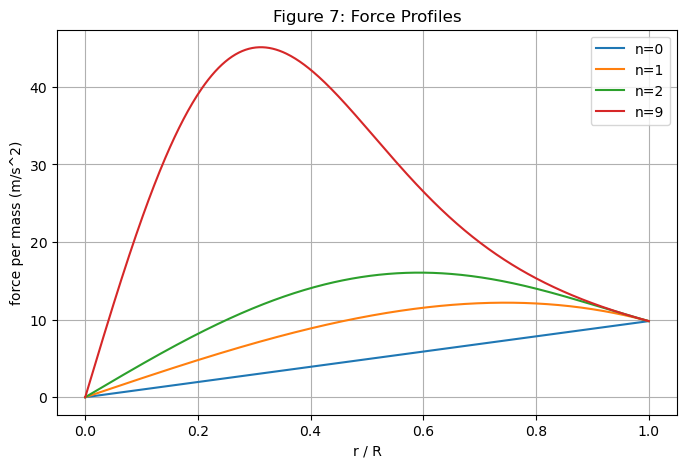

In [17]:
# mass integral
def m_int(n):
    
    # integrating density shape
    val, err = quad(lambda x: rho_shape(x, n) * x**2, 0, R)
    
    return val

# enclosed mass integral
def m_enc(r_val, n):
    
    # integrating inside radius
    val, err = quad(lambda x: rho_shape(x, n) * x**2, 0, r_val)
    
    return val

# acceleration magnitude
def a_mag(r_val, n):
    
    if r_val == 0:
        return 0
    
    # finding mass fraction
    frac = m_enc(r_val, n) / m_int(n)
    
    # finding acceleration
    return g0 * frac * R**2 / r_val**2

# plotting Figure 6
fig, ax = plt.subplots(figsize=(8,5))

for n in ns:
    
    # force profile
    a_vals = np.array([a_mag(rv, n) for rv in r])
    
    # plotting force per mass
    ax.plot(r / R, a_vals, label=f'n={n}')

ax.set_xlabel('r / R')
ax.set_ylabel('force per mass (m/s^2)')
ax.set_title('Figure 7: Force Profiles')
ax.grid()
ax.legend()

plt.show()

### Part 5, Section C (Equations of Motion)

In [18]:
# acceleration with direction
def acc_y(y, n):
    
    r_now = abs(y)
    
    if r_now == 0:
        return 0
    
    # finding direction
    s = np.sign(y)
    
    return -s * a_mag(r_now, n)

# defining system
def tunnel_n(t, z, n):
    
    y, v = z
    
    # finding derivatives
    dydt = v
    dvdt = acc_y(y, n)
    
    return [dydt, dvdt]

# center event
def center_n(t, z):
    
    y, v = z
    
    return y

center_n.terminal = True
center_n.direction = -1

# initial values
z0_5 = [R, 0]

# making storage lists
sols = {}
times = {}
speeds = {}

# solving for each n
for n in ns:
    
    sol = solve_ivp(
        lambda t, z: tunnel_n(t, z, n),
        (0, 4000),
        z0_5,
        events=center_n,
        max_step=1
    )
    
    # storing solution
    sols[n] = sol
    
    # storing center time and speed
    t_cen = sol.t_events[0][0]
    v_cen = np.interp(t_cen, sol.t, sol.y[1])
    
    times[n] = t_cen
    speeds[n] = abs(v_cen)

# answers
for n in ns:
    
    print(f"n = {n}")
    print(f"time to center = {times[n]:.3f} s")
    print(f"speed at center = {speeds[n]:.3f} m/s")
    print()

n = 0
time to center = 1265.870 s
speed at center = 7905.663 m/s

n = 1
time to center = 1095.239 s
speed at center = 10458.209 m/s

n = 2
time to center = 1033.873 s
speed at center = 12183.445 m/s

n = 9
time to center = 942.681 s
speed at center = 18371.571 m/s



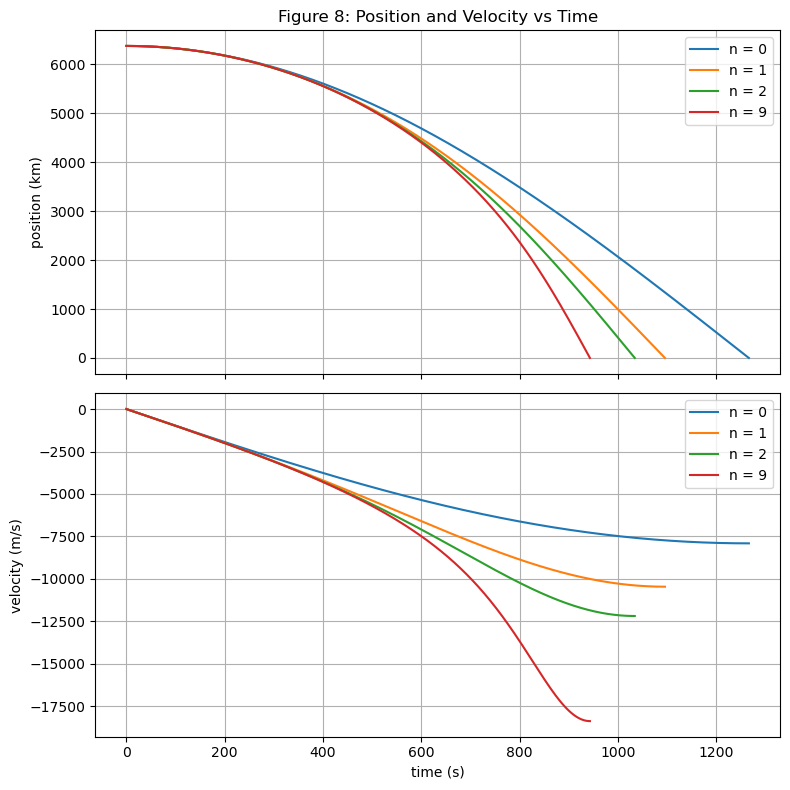

In [19]:
# Figure 7: position and velocity for different n values

fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for n in ns:
    
    # getting time, position, and velocity
    t_now = sols[n].t
    y_now = sols[n].y[0]
    v_now = sols[n].y[1]
    
    # plotting position
    ax[0].plot(t_now, y_now / 1000, label=f'n = {n}')
    
    # plotting velocity
    ax[1].plot(t_now, v_now, label=f'n = {n}')

# labeling position plot
ax[0].set_ylabel('position (km)')
ax[0].set_title('Figure 8: Position and Velocity vs Time')
ax[0].legend()
ax[0].grid(True)

# labeling velocity plot
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('velocity (m/s)')
ax[1].legend()
ax[1].grid(True)

fig.tight_layout()
plt.show()

### Part 5 discussion

As n gets larger, the density becomes more concentrated near the center of Earth. The force at the surface is the same for all n because the total mass is kept the same.

Larger n concentrates more mass near the center, so the object reaches a higher central speed and reaches the center faster.

---

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [20]:
#  moon constants
R_m = 1.737e6
g_m = 1.62

# finding moon tunnel time
T_m = 2 * np.pi * np.sqrt(R_m / g_m)
t_m_center = T_m / 4

print(f"moon time to center = {t_m_center:.3f} s")
print(f"moon full period = {T_m:.3f} s")

moon time to center = 1626.531 s
moon full period = 6506.123 s


In [21]:
# earth density ratio
rho_e = g0 / R

# moon density ratio
rho_m = g_m / R_m

# comparing moon to earth
rho_ratio = rho_m / rho_e

print(f"moon density / earth density = {rho_ratio:.3f}")

moon density / earth density = 0.606


In [22]:
# checking density and fall time relationship
print(f"earth time to center = {t_center:.3f} s")
print(f"moon time to center = {t_m_center:.3f} s")

print(f"moon/earth density = {rho_ratio:.3f}")
print(f"moon/earth fall time = {t_m_center/t_center:.3f}")
print(f"sqrt(earth density / moon density) = {np.sqrt(1/rho_ratio):.3f}")

earth time to center = 1265.870 s
moon time to center = 1626.531 s
moon/earth density = 0.606
moon/earth fall time = 1.285
sqrt(earth density / moon density) = 1.285


### Part 6 discussion

The moon takes longer than Earth because its average density is lower. For a constant-density sphere, the fall time depends on density like

$$
t \propto \frac{1}{\sqrt{\rho}}
$$

So the time does not scale linearly with density. If density gets smaller, the fall time gets larger by the square-root relationship.

---

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

In [23]:
# setting longer time
t_max = 50000
t_new = np.linspace(0, t_max, 6000)

# solving longer orbits
sols7 = {}

for n in [0, 9]:
    
    sol = solve_ivp(
        lambda t, z: tunnel_n(t, z, n),
        (0, t_max),
        z0_5,
        t_eval=t_new,
        max_step=1
    )
    
    sols7[n] = sol

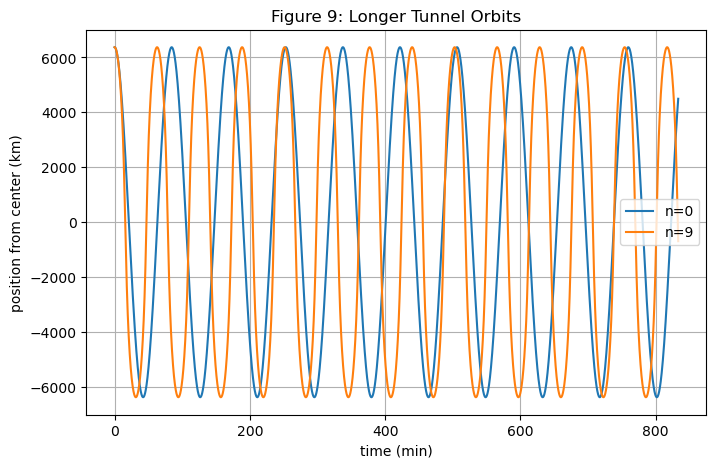

In [24]:
# plotting
fig, ax = plt.subplots(figsize=(8,5))

for n in [0, 9]:
    
    ax.plot(sols7[n].t / 60, sols7[n].y[0] / 1000, label=f'n={n}')

ax.set_xlabel('time (min)')
ax.set_ylabel('position from center (km)')
ax.set_title('Figure 9: Longer Tunnel Orbits')
ax.grid()
ax.legend()

plt.show()

In [25]:
# doing fourier transforms
freqs7 = {}
power7 = {}

for n in [0, 9]:
    
    # storing position data
    y_now = sols7[n].y[0]
    
    # subtracting mean
    y_now = y_now - np.mean(y_now)
    
    # finding time step
    dt = sols7[n].t[1] - sols7[n].t[0]
    
    # finding fft
    Y = np.fft.rfft(y_now)
    f = np.fft.rfftfreq(len(y_now), dt)
    
    # storing power
    freqs7[n] = f
    power7[n] = np.abs(Y)**2

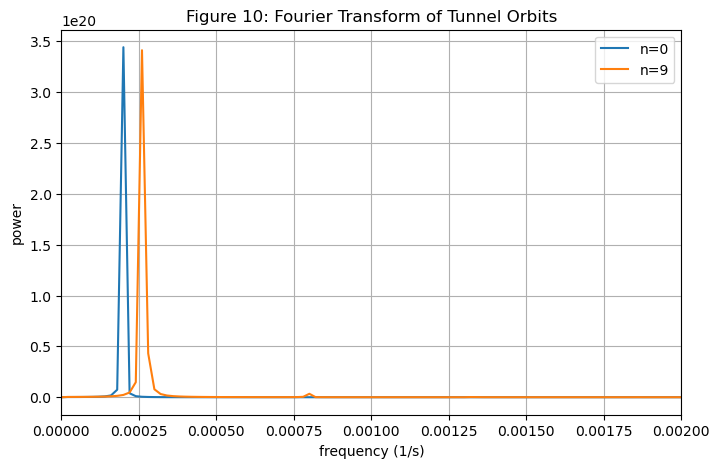

In [26]:
# plotting spectra
fig, ax = plt.subplots(figsize=(8,5))

for n in [0, 9]:
    
    # plotting power
    ax.plot(freqs7[n], power7[n], label=f'n={n}')

ax.set_xlim(0, 0.002)
ax.set_xlabel('frequency (1/s)')
ax.set_ylabel('power')
ax.set_title('Figure 10: Fourier Transform of Tunnel Orbits')
ax.grid()
ax.legend()

plt.show()

In [27]:
# printing main frequencies
for n in [0, 9]:
    
    # ignoring zero frequency
    f = freqs7[n][1:]
    p = power7[n][1:]
    
    # finding biggest peak
    i = np.argmax(p)
    
    main_f = f[i]
    main_T = 1 / main_f
    
    print(f"n = {n}")
    print(f"main frequency = {main_f:.6e} 1/s")
    print(f"main period = {main_T:.3f} s")
    print()

n = 0
main frequency = 1.999667e-04 1/s
main period = 5000.833 s

n = 9
main frequency = 2.599567e-04 1/s
main period = 3846.795 s



### Part 7 discussion

For n=0, the power spectrum has one strong main peak. This makes sense because the constant-density Earth gives simple harmonic motion, so the motion is basically one clean frequency.

For n=9, the spectrum is less clean. The density is more concentrated near the center, so the force is not exactly the same linear spring-like force as the n=0 case. Because of that, the motion is not a perfect sine wave, and the Fourier transform shows extra power at other frequencies.

(the FFT period is close but not exact because the finite time window limits the frequency resolution)